# Plots

## Packages and specific functions

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
plt.style.use('seaborn-v0_8-colorblind')
from my_functions import environmental_and_occupational_risks, behavioural_risks, metabolic_risks, overarching_risks
from my_functions import plot_risk_factors, plot_gbd
import numpy as np
from pdf2image import convert_from_path
from PIL import Image

## Load data generated in the mother script

In [55]:
df=pd.read_csv('./data/processed_data/df.csv')
df_comp=pd.read_csv('./data/processed_data/df_comp.csv')
temps_comp=pd.read_csv('./data/processed_data/temps_comp.csv')
temps=pd.read_csv('./data/processed_data/temps.csv')
#summary_95CI=pd.read_csv('./data/processed_data/95CI_summary_all_deaths.csv')
#summary_95CI_individual=pd.read_csv('./data/processed_data/diet_matched_comps_cohort.csv')
results_df=pd.read_csv('data/processed_data/dietary_deep_dive.csv')

### Make the dietary and physical activity df and the rankings calculations.

In [44]:
df_diet=df_comp[(df_comp['Risk_factor'].str.contains('Diet')) | (df_comp['Risk_factor'].str.contains('physical activity'))]
len(df_diet.Risk_factor.unique())
# Separate the dietary data by measure (Death or DALY)
df_diet_death = df_diet[df_diet['measure'] == 'Deaths'].copy()  # Use .copy() to avoid SettingWithCopyWarning
df_diet_DALY = df_diet[df_diet['measure'] == 'DALYs'].copy()

# Rank Risk_factor by 'val' within each 'year_gbd' for Deaths and DALYs
df_diet_death['Rank'] = df_diet_death.groupby('year_gbd')['val'].rank(ascending=False, method='dense')
df_diet_DALY['Rank'] = df_diet_DALY.groupby('year_gbd')['val'].rank(ascending=False, method='dense')
df_diet_comp=pd.concat([df_diet_death, df_diet_DALY])

df_diet_comp.Rank.max()

df_diet_comp = df_diet_comp[df_diet_comp['Risk_factor'] != 'Dietary risks']

df_diet_comp['Rank'] = df_diet_comp.groupby(['year_gbd', 'measure'])['val'].rank(ascending=False, method='dense')

df_diet_comp=df_diet_comp[df_diet_comp['Risk_factor']!='Dietary risks']

df_diet_comp.to_csv('./data/dietary_ranks.csv')

## Figure 1

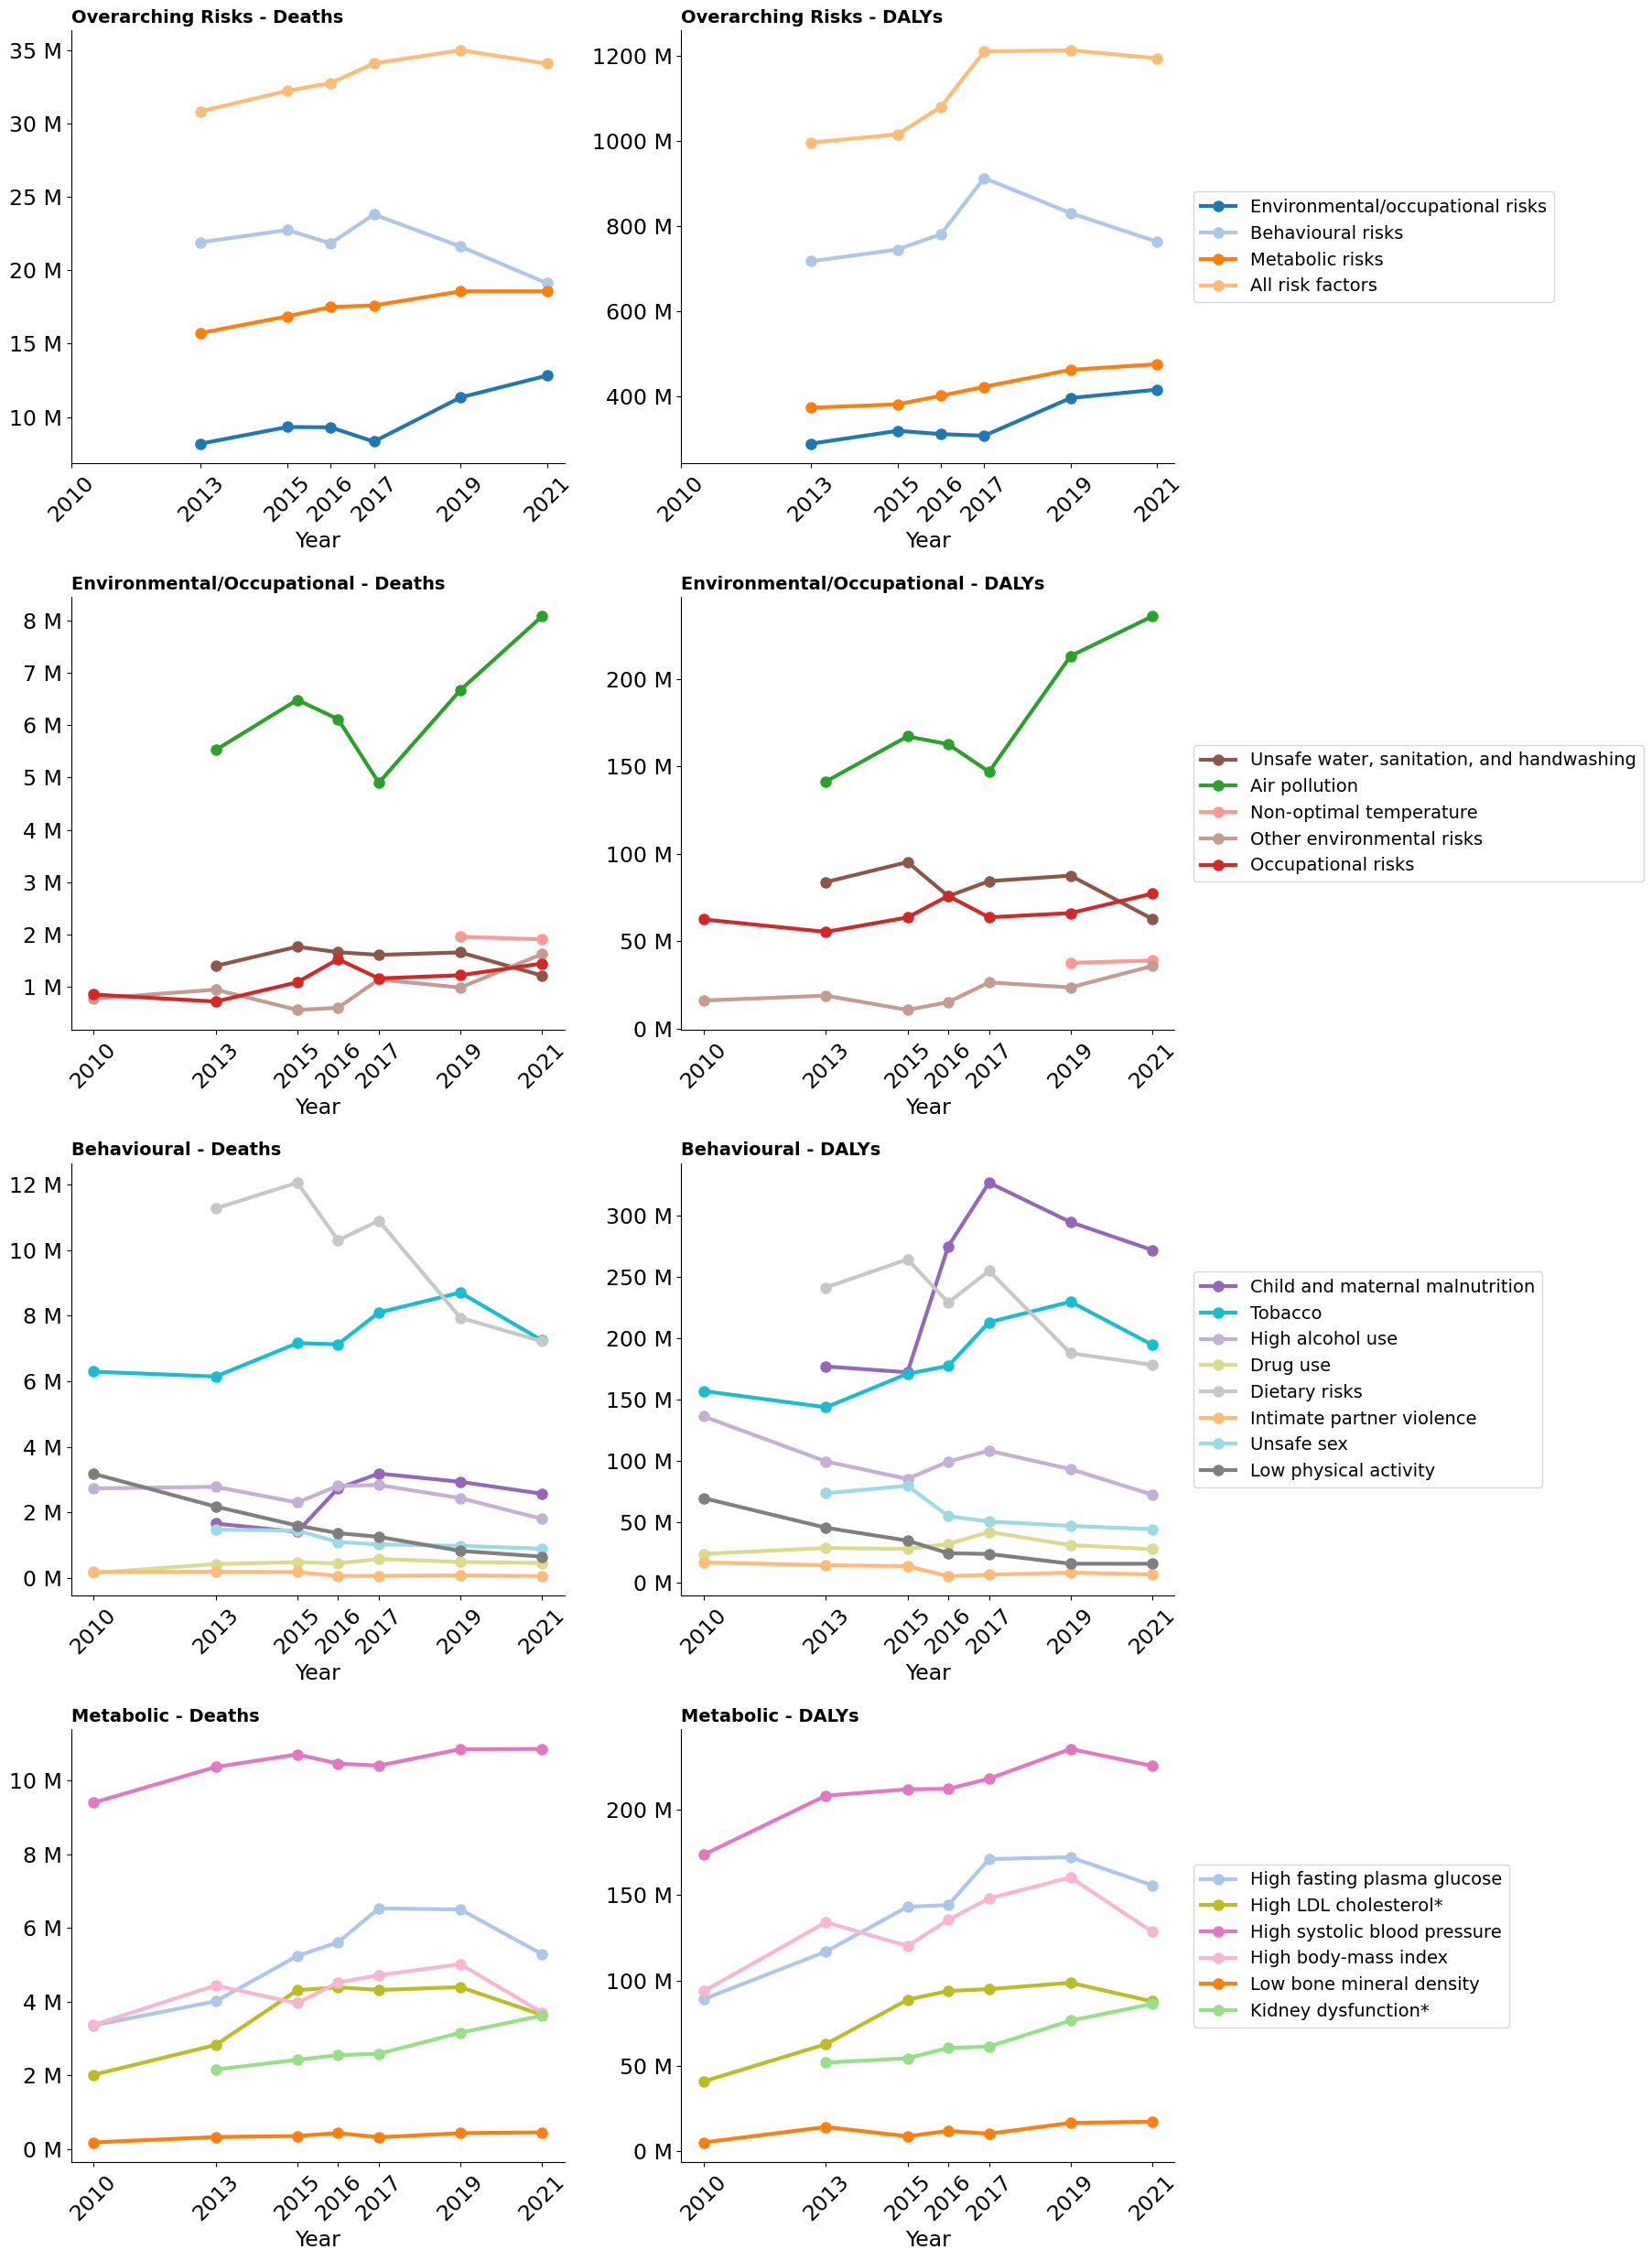

In [45]:
plt.rcParams.update({'font.size': 17})
def millions_formatter(x, pos=None):
    scaled = x * 1e-6
    s = f"{scaled:.1f}"
    if s.endswith(".0"):
        s = s[:-2]          # drop the trailing ".0"
    return f"{s} M"

formatter_millions = mtick.FuncFormatter(millions_formatter)
#formatter_millions = mtick.FuncFormatter(lambda x, _: f"{x*1e-6:.1f} M".rstrip("0").rstrip(".") + " M")
cmap = plt.get_cmap('tab20')

# --- Colors ---
overarch_color_map = {risk: cmap(i) for i, risk in enumerate(overarching_risks)}
all_level2_risks = list(set(environmental_and_occupational_risks + behavioural_risks + metabolic_risks))
level2_color_map = {risk: cmap(i) for i, risk in enumerate(all_level2_risks)}

# --- Risk groups ---
risk_groups = [
    ('Overarching Risks', overarching_risks, df_comp),
    ('Environmental/Occupational', environmental_and_occupational_risks, temps_comp),
    ('Behavioural', behavioural_risks, temps_comp),
    ('Metabolic', metabolic_risks, temps_comp)
]

measures = ['Deaths', 'DALYs']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 25), sharex=False, sharey=False)

for row_idx, (group_name, risk_list, df_source) in enumerate(risk_groups):
    for col_idx, measure in enumerate(measures):
        ax = axes[row_idx, col_idx]
        df_measure = df_source[df_source['measure'] == measure]

        for risk in risk_list:
            group = df_measure[df_measure['Risk_factor'] == risk]
            if not group.empty:
                color_map = overarch_color_map if group_name == 'Overarching Risks' else level2_color_map
                ax.plot(group['year_gbd'], group['val'], label=risk,
                        marker='o', markersize=8, linewidth=3,
                        color=color_map[risk])

        # Formatting
        ax.set_title(f"{group_name} - {measure}", loc='left', fontsize=14, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('')
        ax.set_xticks([2010, 2013, 2015, 2016, 2017, 2019, 2021])
        ax.tick_params(axis='x', rotation=45)
        ax.yaxis.set_major_formatter(formatter_millions)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Legend per row (only on the right column)
        if col_idx == 1:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels, title=None, loc='center left',
                      bbox_to_anchor=(1.02, 0.5), prop={'size':14}, title_fontsize=16)
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig('./figs/Fig1.pdf', bbox_inches='tight')
plt.show()


# eFigure 2

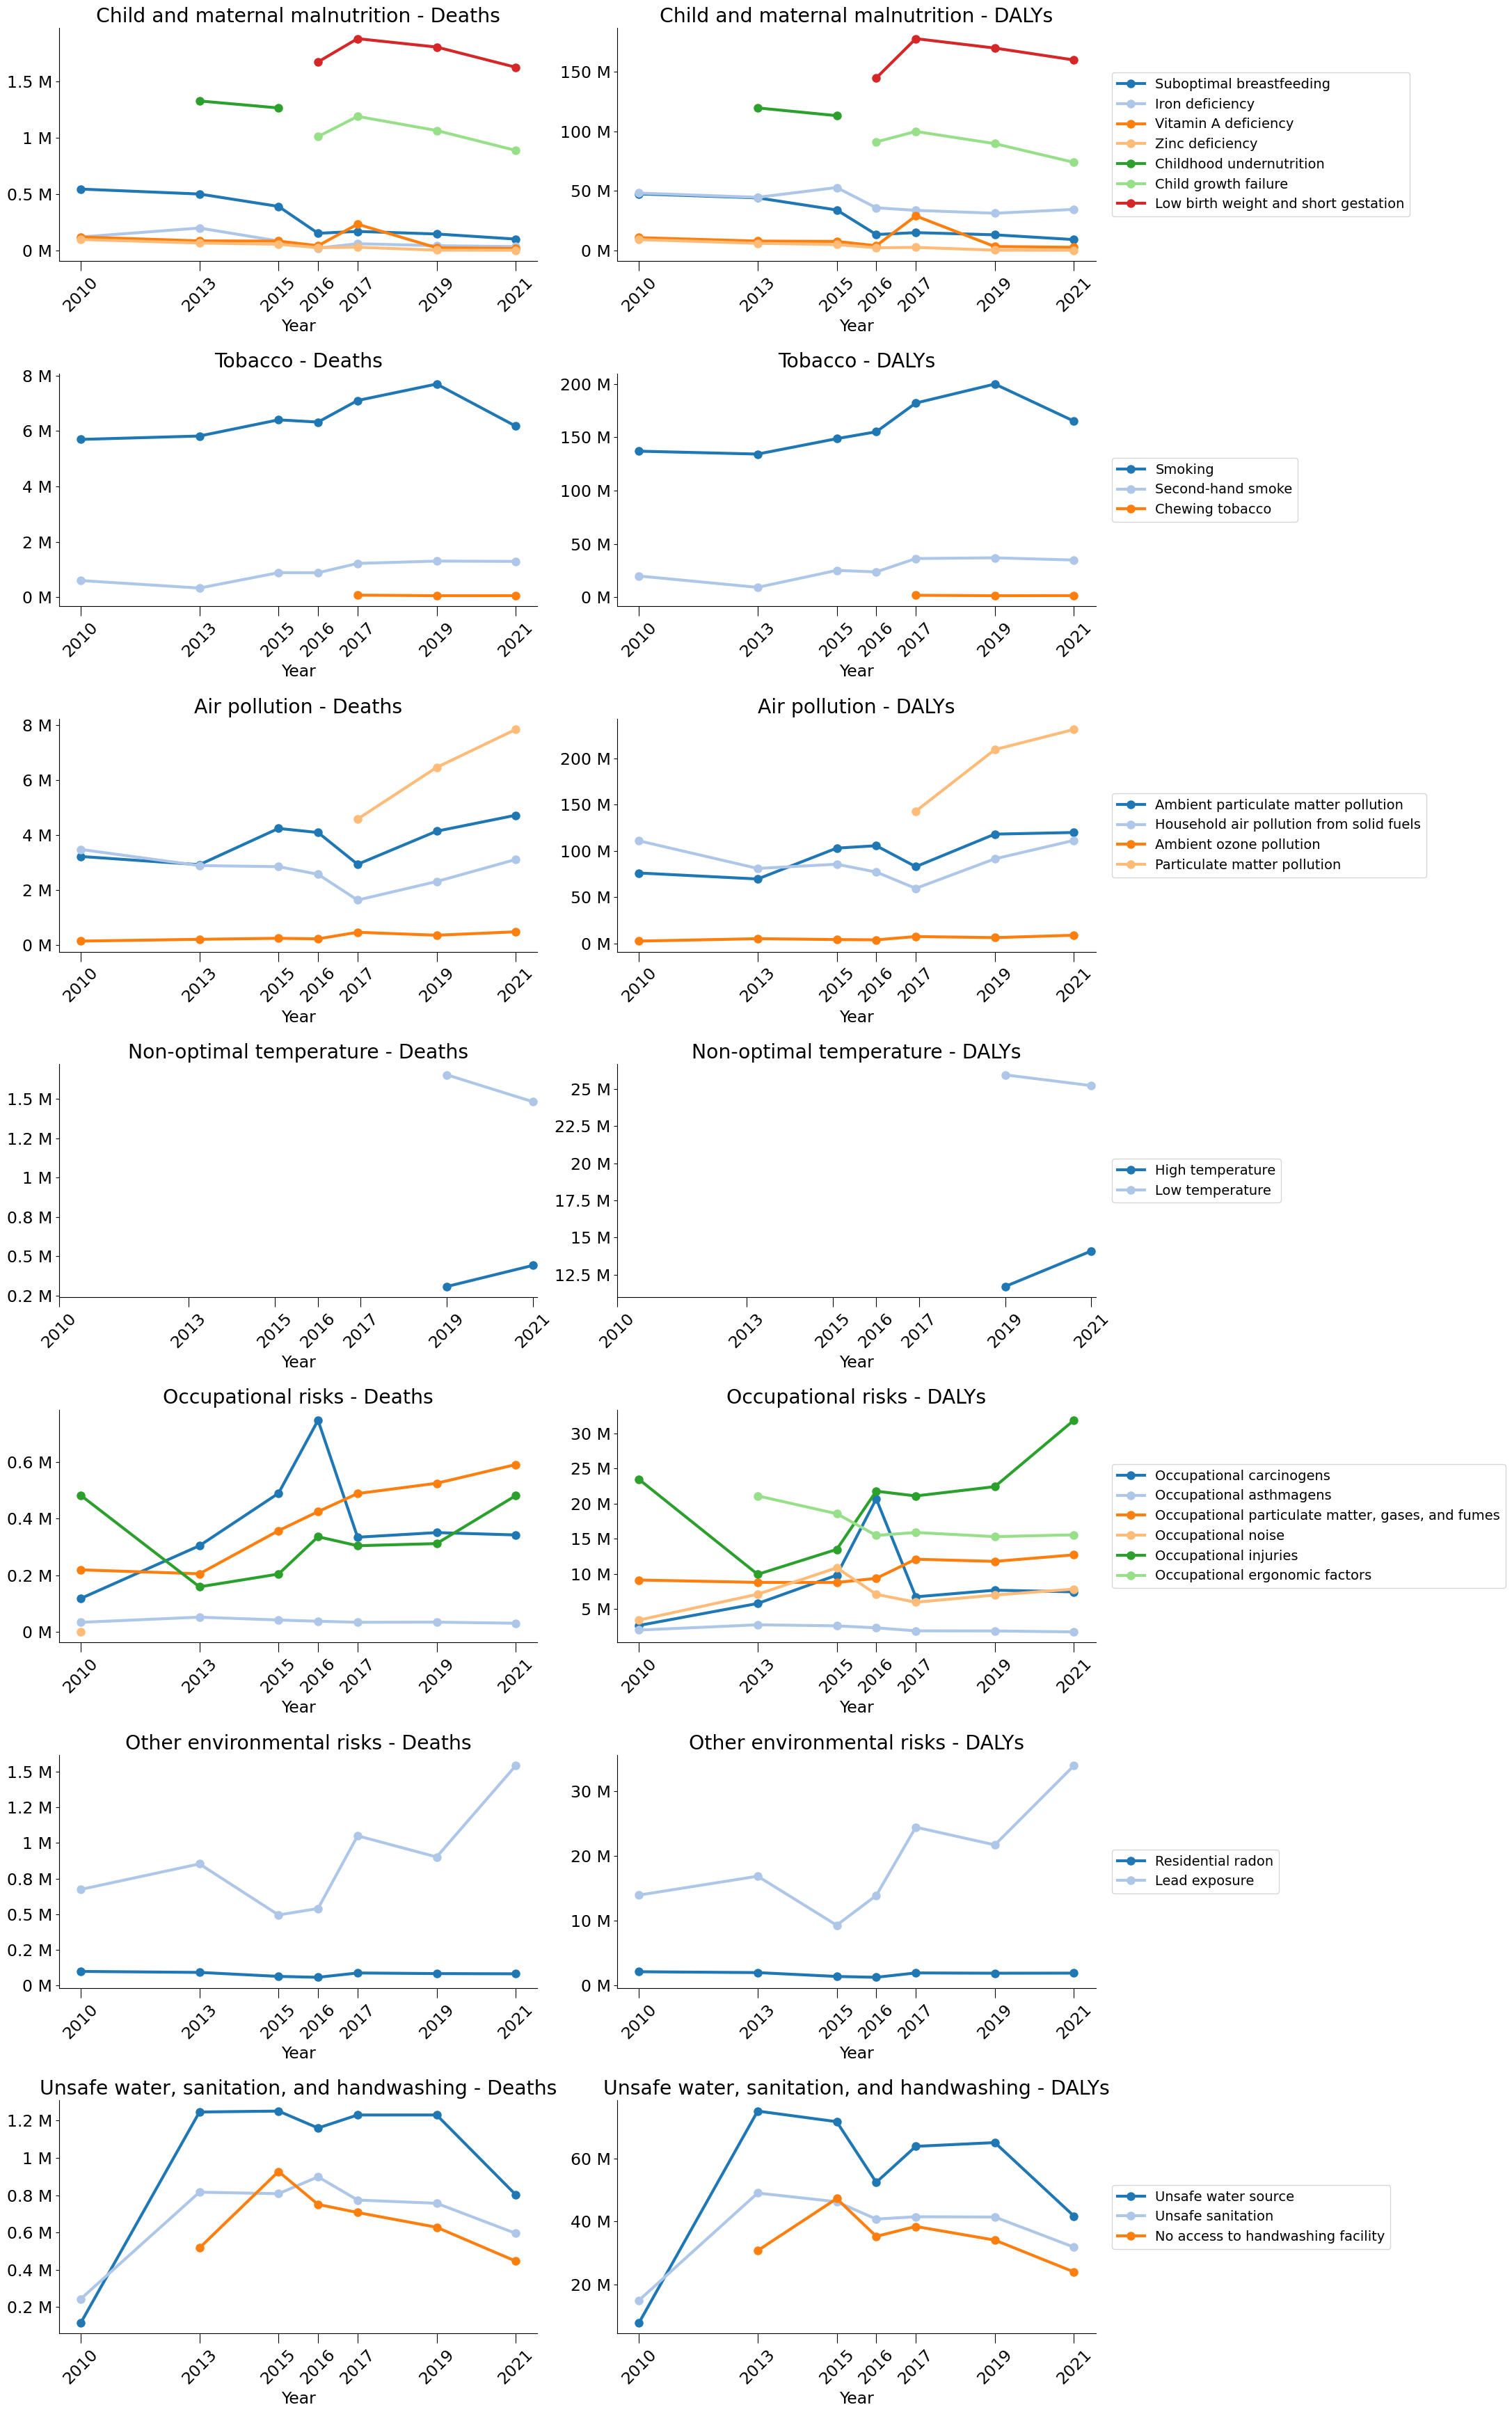

In [46]:
# Filter out 'Other' group
df_plot = temps_comp[temps_comp['Group'] != 'Other']
df_plot = df_plot[df_plot['Group'] != df_plot['Risk_factor']]
df_plot = df_plot[df_plot['Group'] != 'Dietary risks']

# Sort groups by Overarching_group, then alphabetically within each Overarching_group
df_plot = df_plot.sort_values(by=['Overarching_group', 'Group'])
groups = df_plot['Group'].unique()
measures = ['Deaths', 'DALYs']

fig, axes = plt.subplots(len(groups), 2, figsize=(24, 5 * len(groups)), sharex=False, sharey=False)

if len(groups) == 1:
    axes = axes.reshape(1, 2)

cmap = plt.get_cmap('tab20')
for i, group in enumerate(groups):
    legend_handles = []
    legend_labels = []
    for j, measure in enumerate(measures):
        ax = axes[i, j]
        group_df = df_plot[(df_plot['Group'] == group) & (df_plot['measure'] == measure)]
        risk_factors = group_df['Risk_factor'].unique()
        colors = [cmap(k % cmap.N) for k in range(len(risk_factors))]
        color_map = {risk_factors[k]: colors[k] for k in range(len(risk_factors))}
        for risk in risk_factors:
            data = group_df[group_df['Risk_factor'] == risk]
            line, = ax.plot(data['anal_year'], data['val'], label=risk, color=color_map[risk], marker='o', markersize=8, linewidth=3)
            if risk not in legend_labels:
                legend_handles.append(line)
                legend_labels.append(risk)
        ax.set_title(f"{group} - {measure}")
        ax.set_xlabel('Year')
        ax.set_xticks([2010, 2013, 2015, 2016, 2017, 2019, 2021])
        ax.tick_params(axis='x', rotation=45, size=10)
        ax.yaxis.set_major_formatter(formatter_millions)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Legend per row (only on the right column)
        if j == 1:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles, labels, title=None, loc='center left',
                        bbox_to_anchor=(1.02, 0.5), prop={'size':14}, title_fontsize=16)
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig('./figs/eFig2.pdf', bbox_inches='tight')
plt.show()

## Figure 3

### Figure 3A

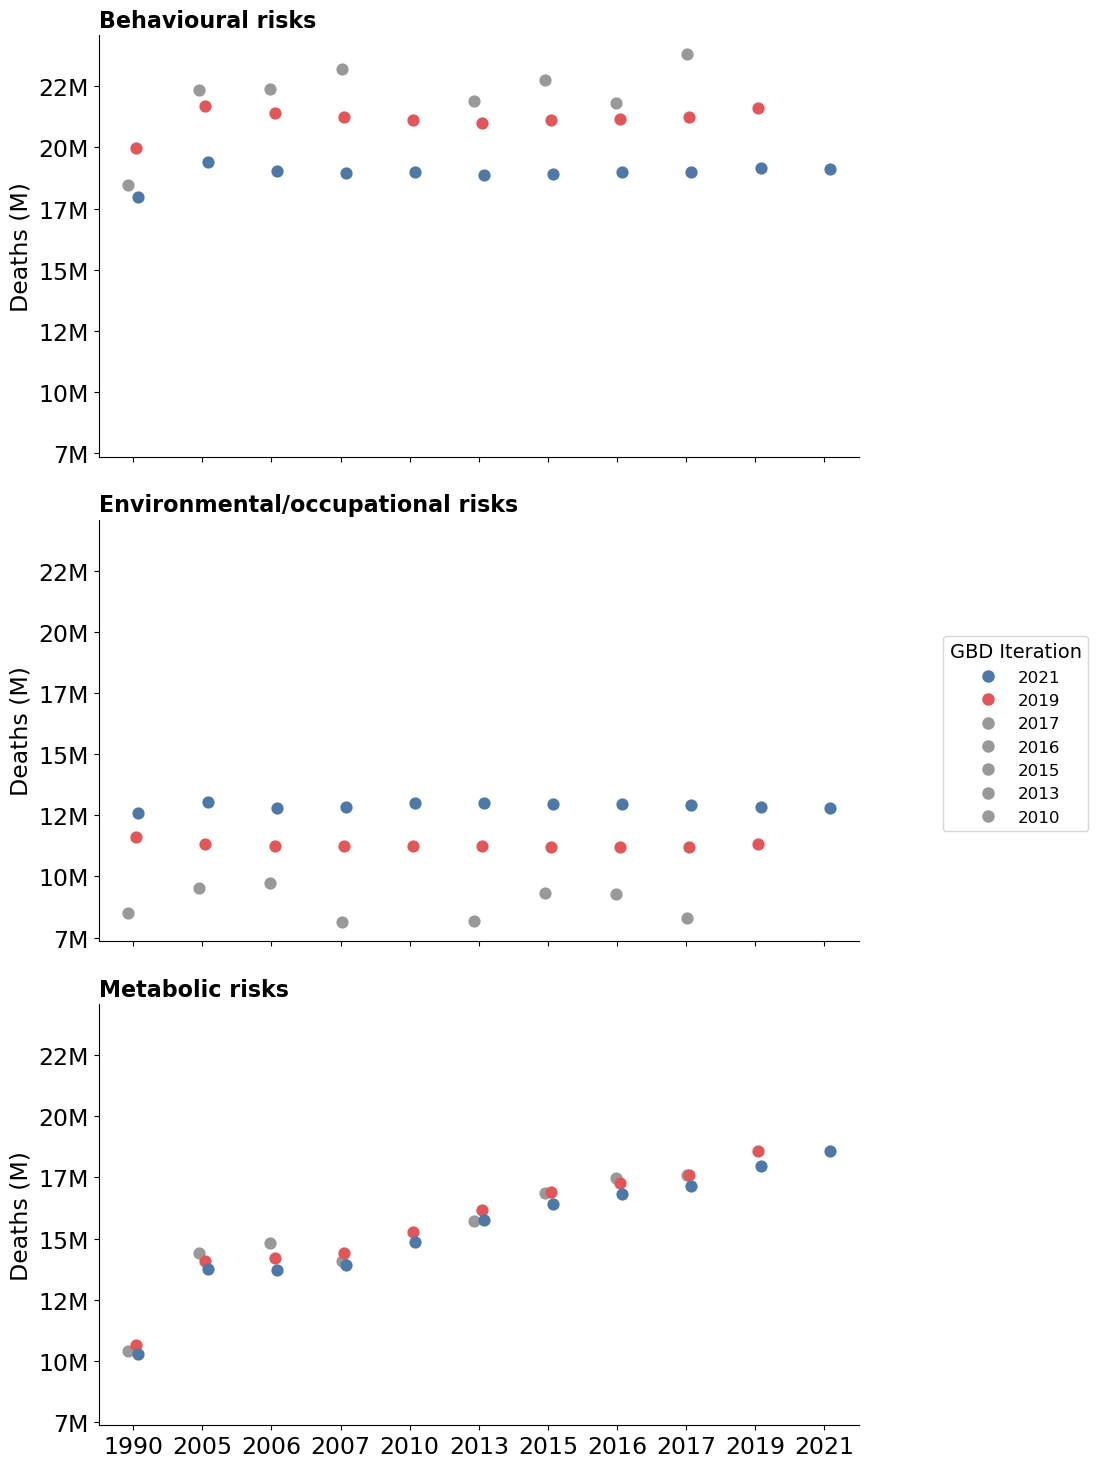

In [ ]:
x=temps[temps['measure']=='Deaths']
x=x[x['Overarching_group']!='Other']
x=x[x['Group']=='Other']
x=x[x['Overarching_group']!='All risk factors']

# Plot all Deaths
plot_gbd(x, measure="Deaths", save_path="./figs/Fig3A - Deaths.pdf")

### Figure 3B

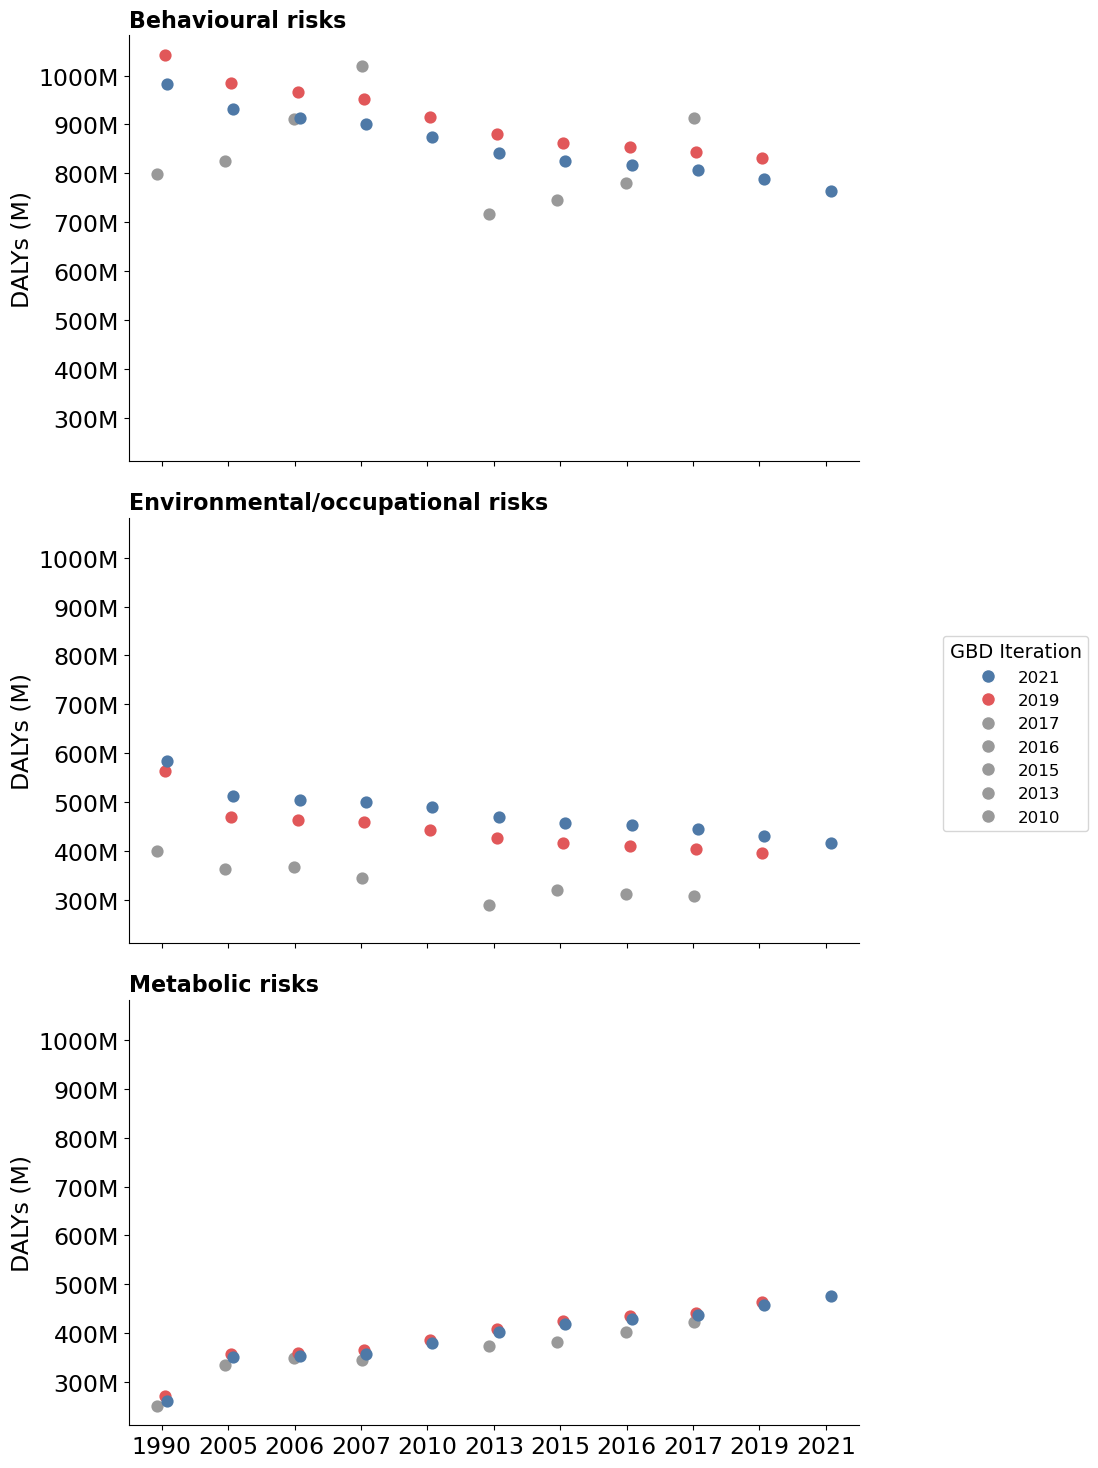

In [ ]:
x=temps[temps['measure']=='DALYs']
x=x[x['Overarching_group']!='Other']
x=x[x['Group']=='Other']
x=x[x['Overarching_group']!='All risk factors']
plot_gbd(x, measure="DALYs", save_path="./figs/Fig3B DALYs.pdf")

## eFigure 4

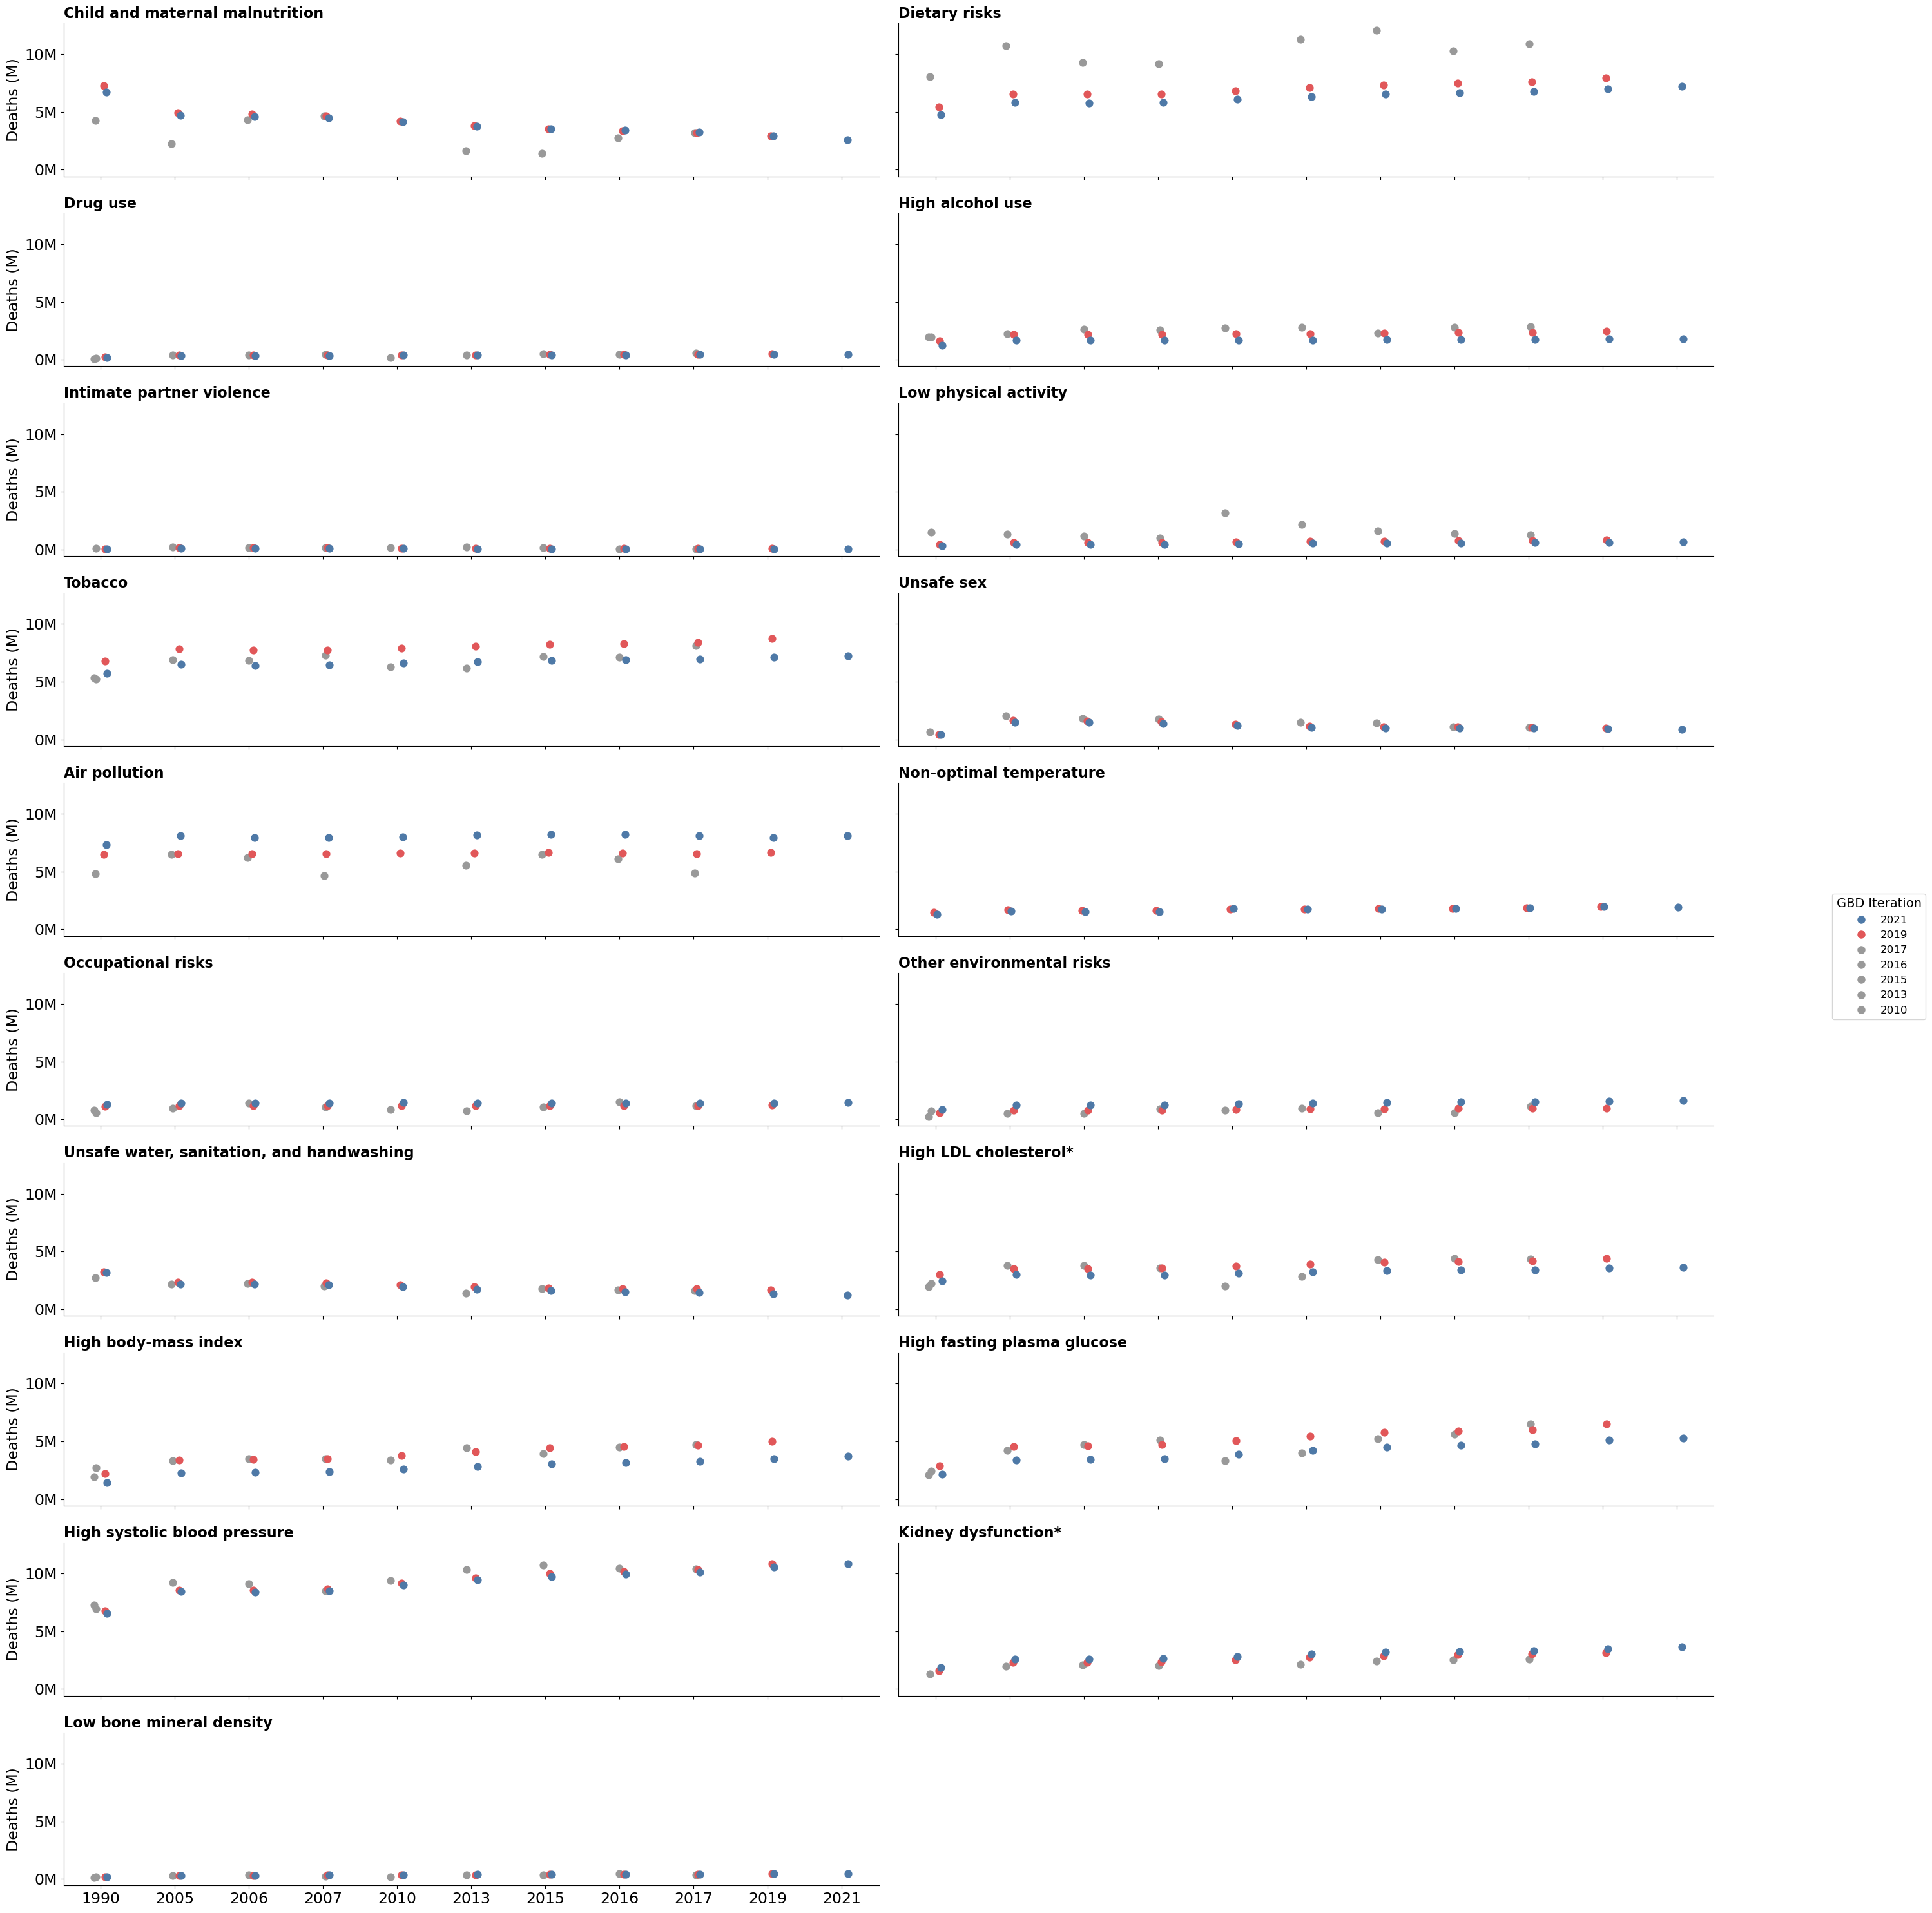

In [49]:
x=temps[temps['measure']=='Deaths']
x=x[x['Overarching_group']!='Other']
x=x[x['Group']==x['Risk_factor']]
x=x[x['Overarching_group']!='All risk factors']
plot_gbd(x, measure="Deaths", ncols=2,save_path="./figs/eFig4.pdf",figsize=(30, 30))

## eFigure 5

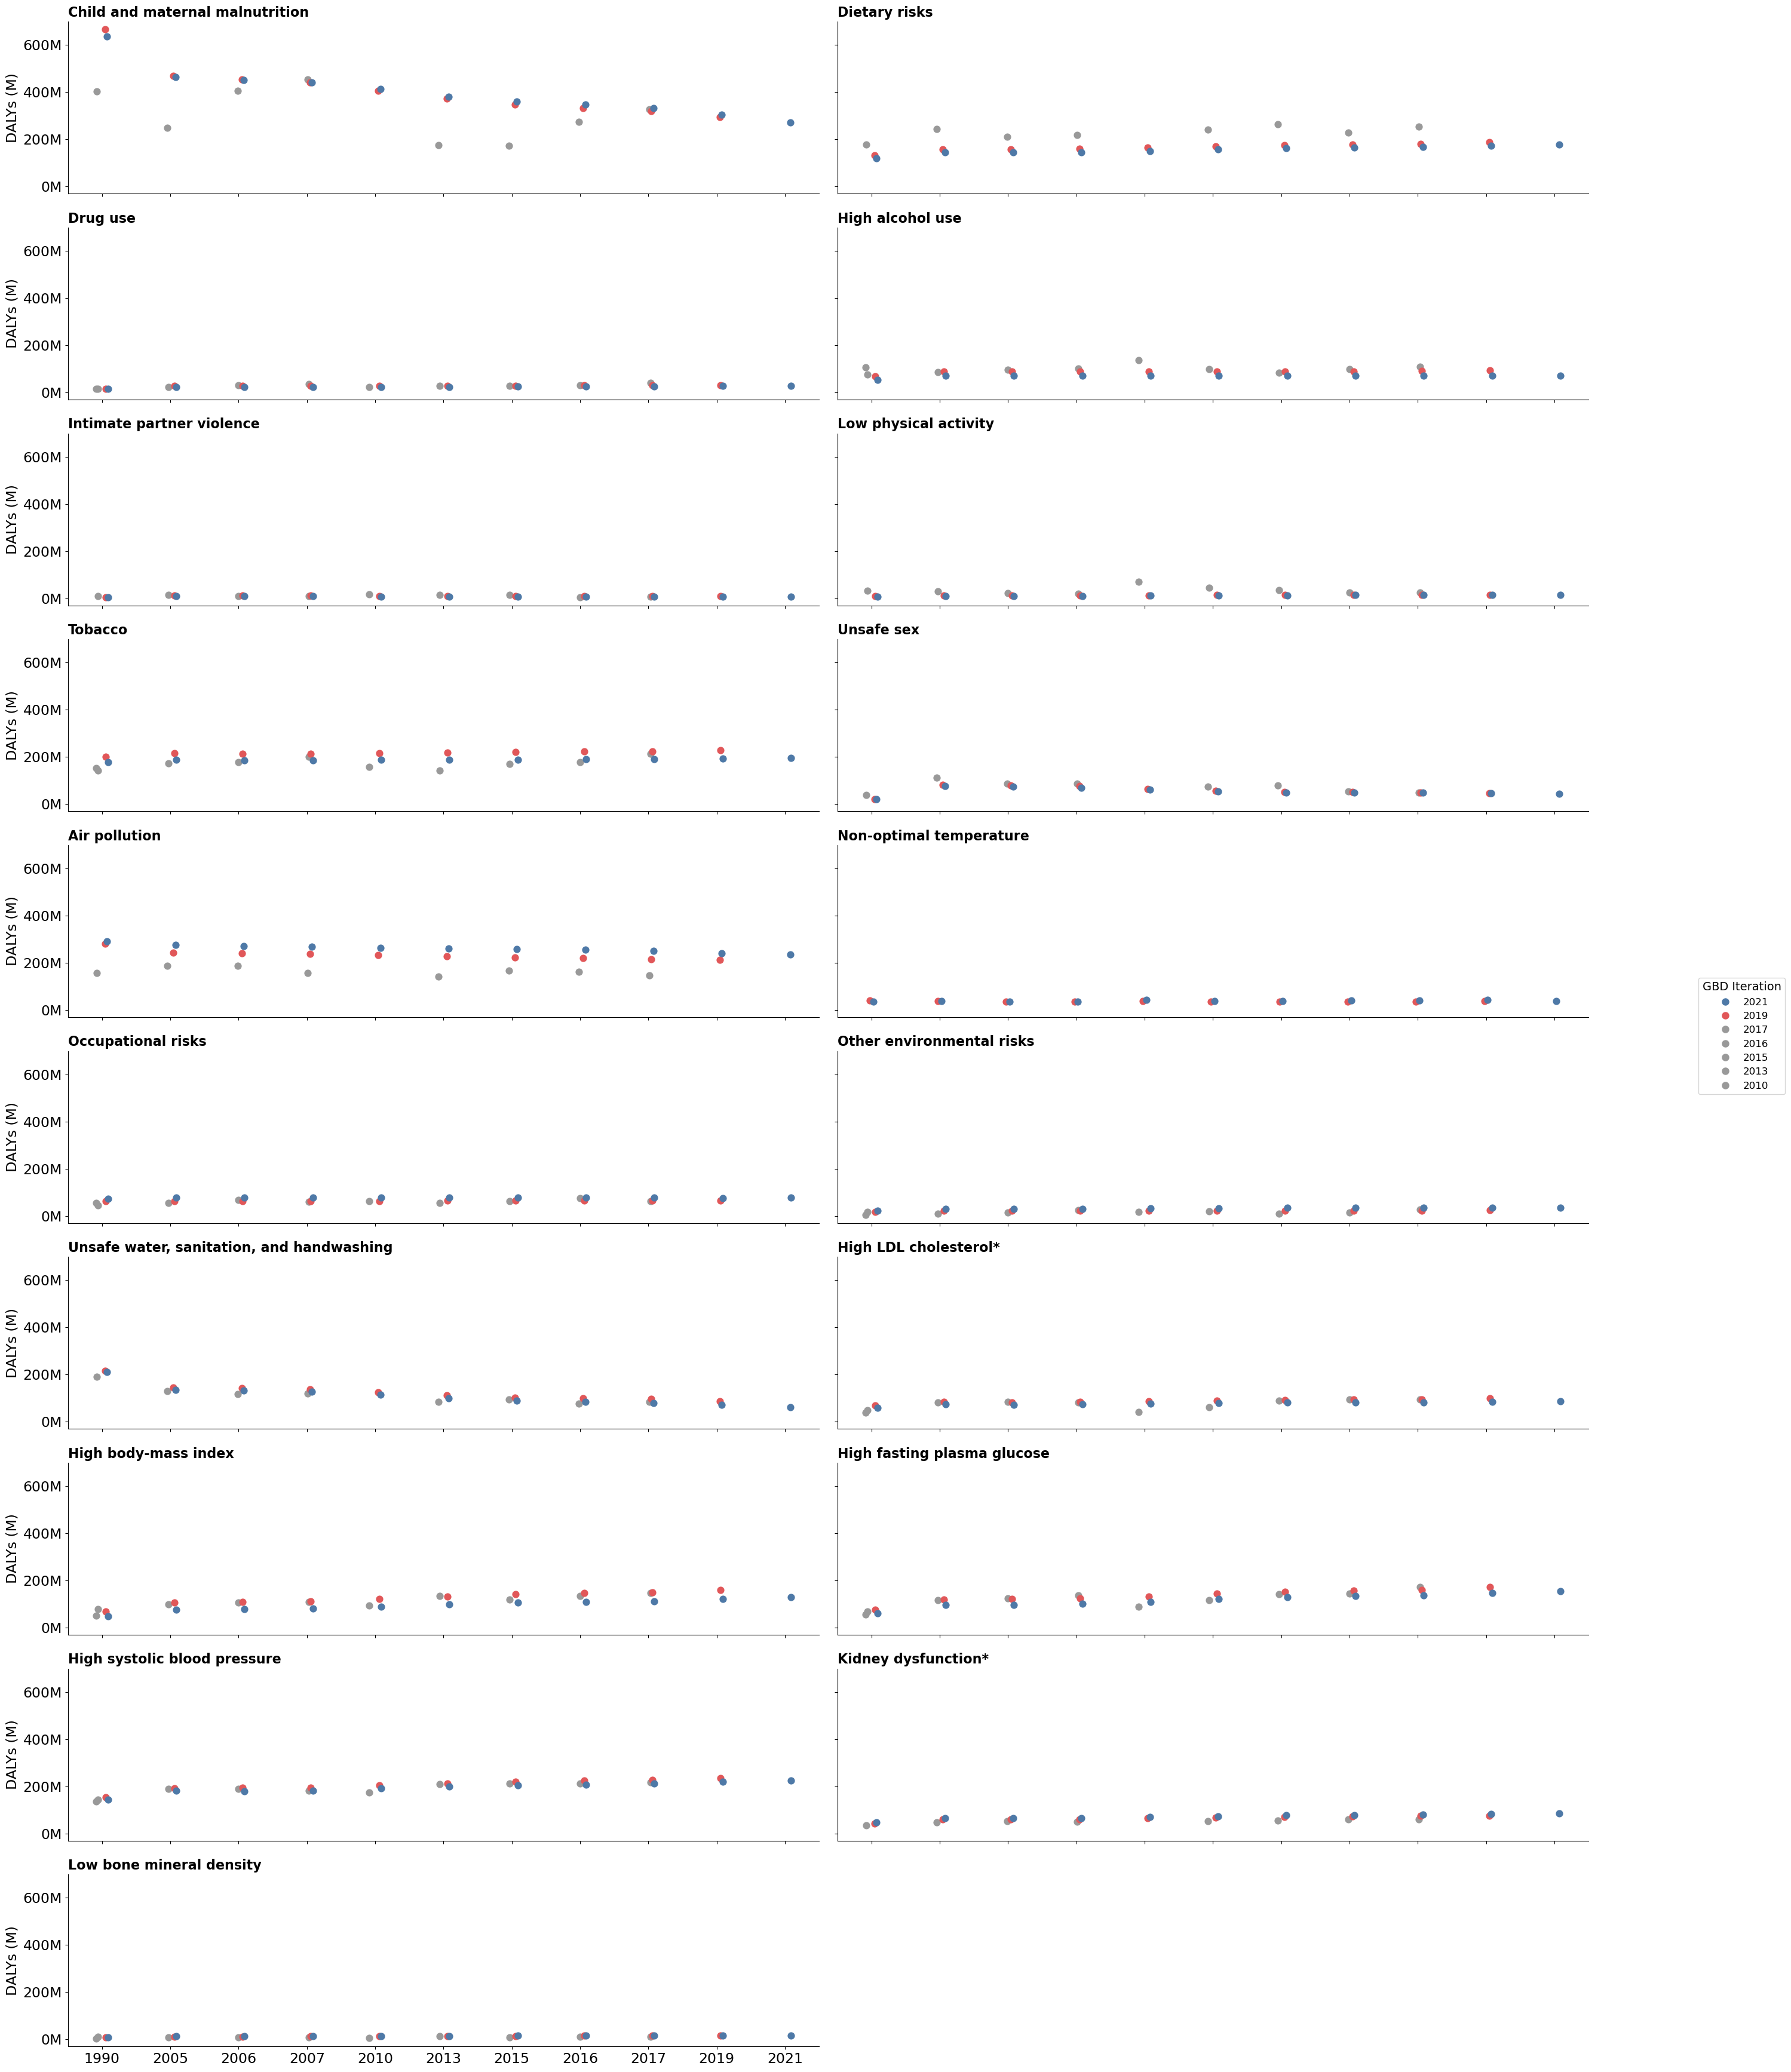

In [50]:
x=temps[temps['measure']=='DALYs']
x=x[x['Overarching_group']!='Other']
x=x[x['Group']==x['Risk_factor']]
x=x[x['Overarching_group']!='All risk factors']
plot_gbd(x, measure="DALYs", ncols=2,save_path="./figs/eFig5.pdf",figsize=(30, 35))

## Figure 5

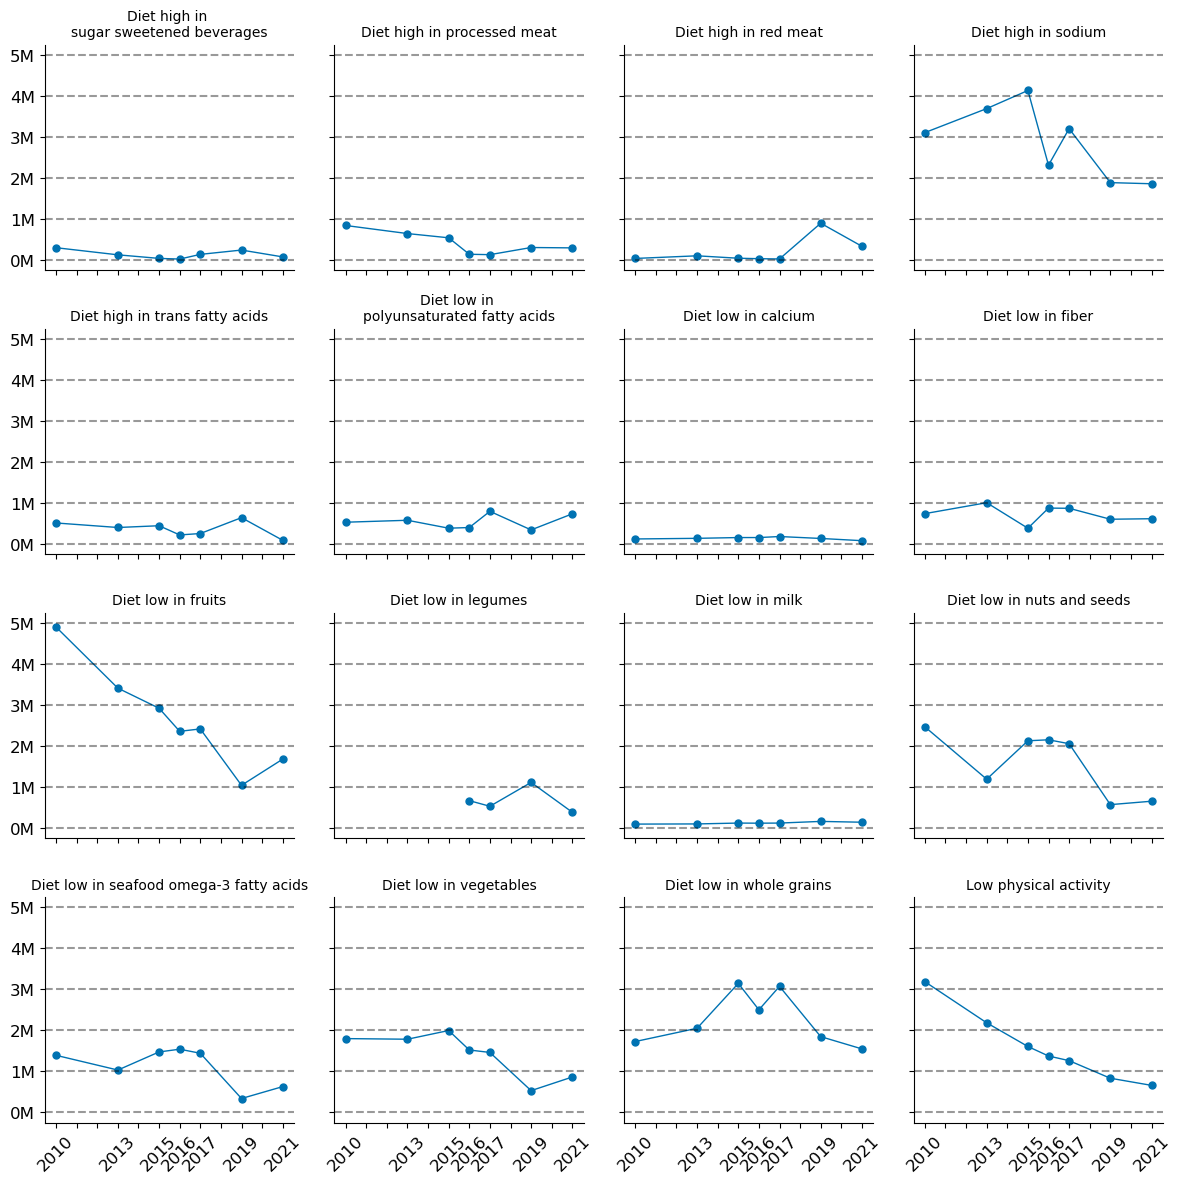

In [51]:
# Deaths
plot_risk_factors(df_diet_comp, measure="Deaths",
                  filename="./figs/eFig6A.pdf",
                  y_tick_step=1_000_000)

## eFigure 6B

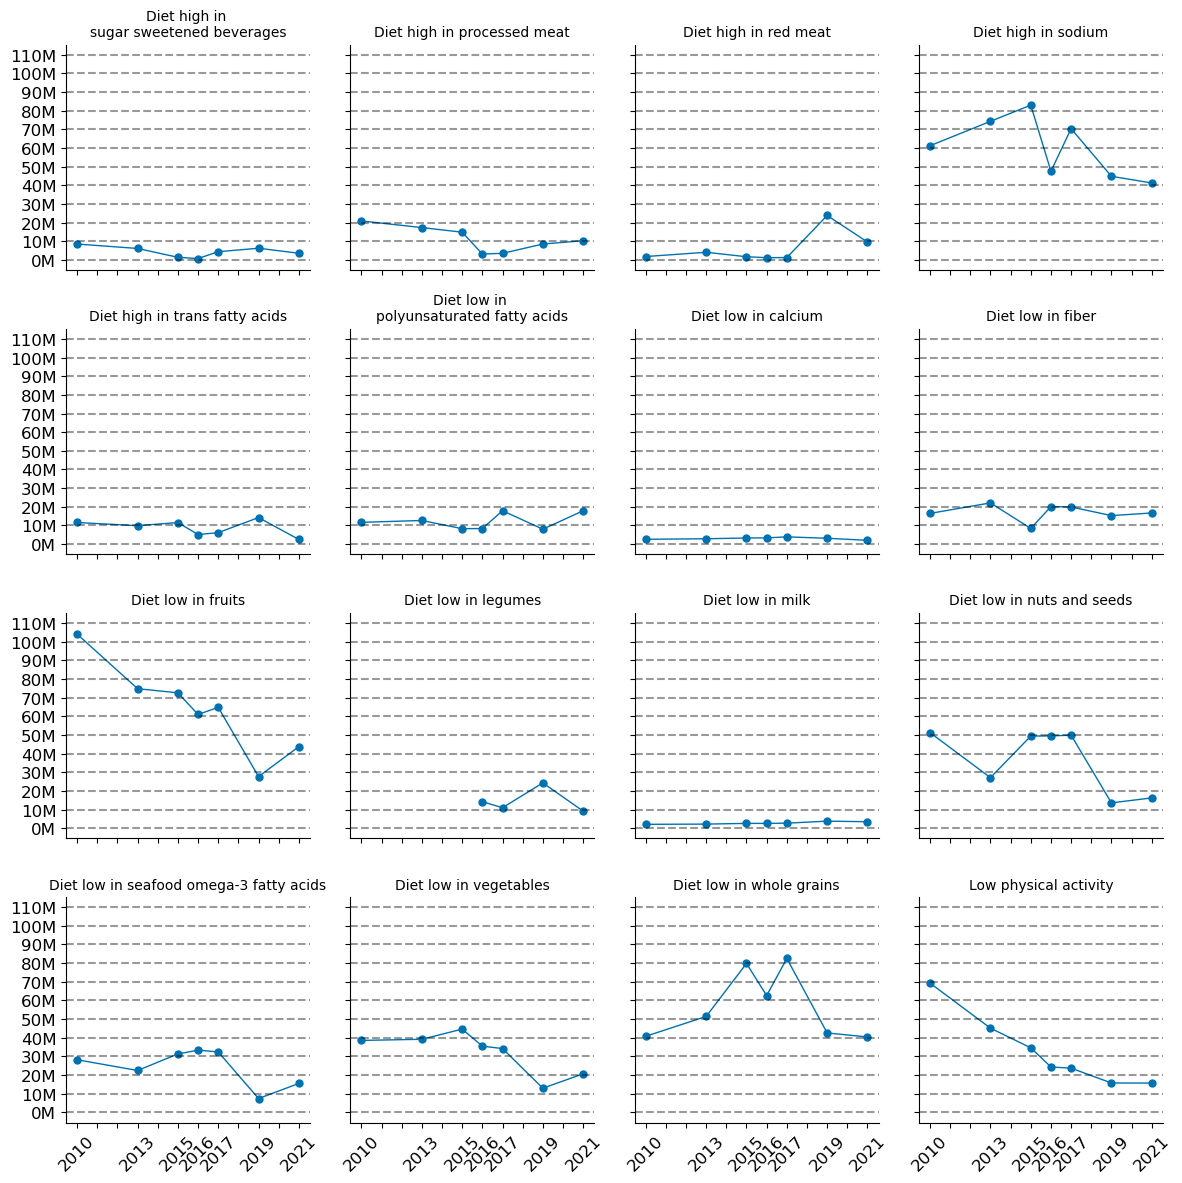

In [52]:
# DALYs
plot_risk_factors(df_diet_comp, measure="DALYs",
                  filename="./figs/eFig6B.pdf",
                  y_tick_step=10_000_000)

## eFigure 6 combined

In [ ]:
# Convert the first page of each PDF to images
deaths_img = convert_from_path("./figs/eFig6A.pdf", dpi=300)[0]
dalys_img = convert_from_path("./figs/eFig6B.pdf", dpi=300)[0]

# Ensure same height
if deaths_img.height != dalys_img.height:
    new_height = min(deaths_img.height, dalys_img.height)
    deaths_img = deaths_img.resize(
        (int(deaths_img.width * new_height / deaths_img.height), new_height)
    )
    dalys_img = dalys_img.resize(
        (int(dalys_img.width * new_height / dalys_img.height), new_height)
    )

# Combine side by side
combined_width = deaths_img.width + dalys_img.width
combined_img = Image.new("RGB", (combined_width, deaths_img.height), (255, 255, 255))
combined_img.paste(deaths_img, (0, 0))
combined_img.paste(dalys_img, (deaths_img.width, 0))

# Save as a single PDF page
combined_img.save("./figs/eFig6.pdf", "PDF", resolution=300)

print("✅ Combined figure saved as ./figs/eFig 6 combo.pdf")


✅ Combined figure saved as ./figs/eFig 6 combo.pdf


# Figure 4
95%CI to point estimate comparisons

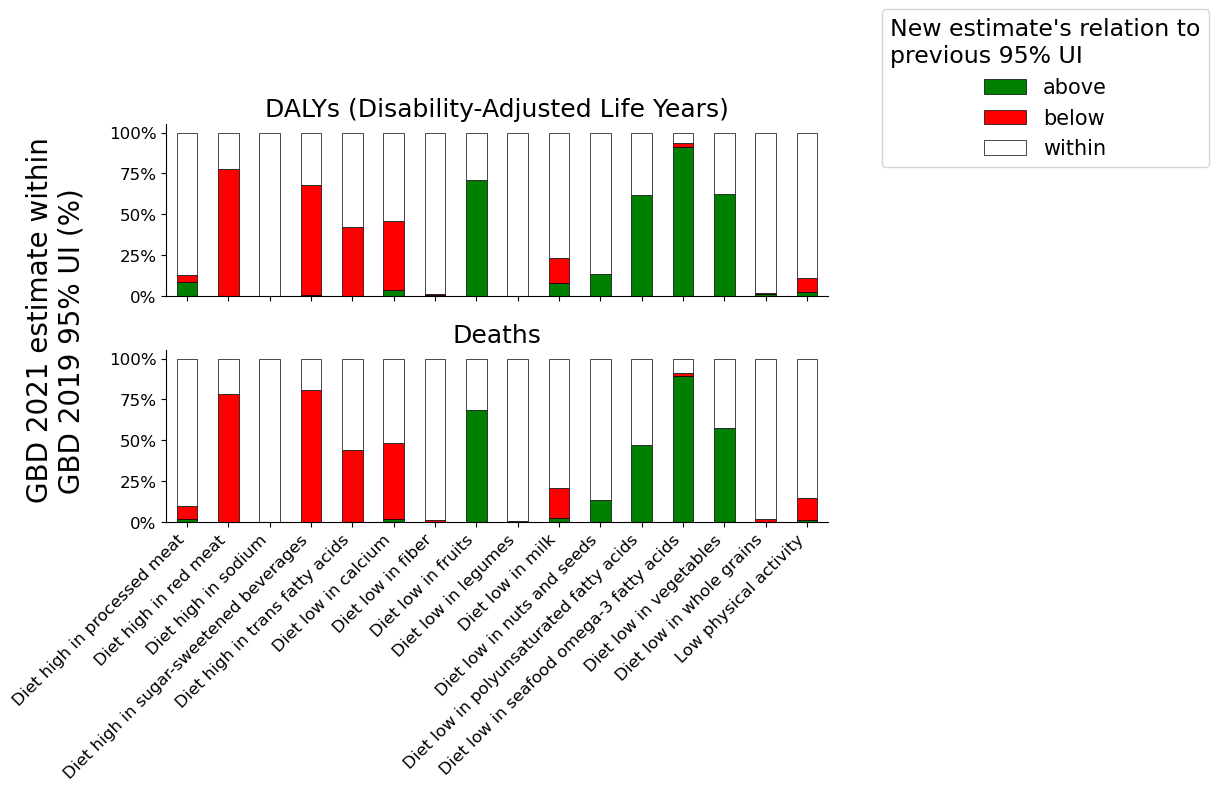

In [56]:
# Plot by measure name
measure_names = results_df['measure_name'].unique()
num_measures = len(measure_names)
fig, axes = plt.subplots(num_measures, 1, figsize=(10, 8 * num_measures), sharex=True, sharey=True)

# Create a common axis labels
fig.text(0.5, 0.04, '', ha='center', fontsize=20)
fig.text(0.03, 0.8, 'GBD 2021 estimate within\n GBD 2019 95% UI (%)', va='center', rotation='vertical', fontsize=20)
colors = {'within': 'white', 'above': 'green', 'below': 'red'}

# Plot each measure name
for ax, measure in zip(axes, measure_names):
    measure_df = results_df[results_df['measure_name'] == measure]
    breakdown = measure_df.groupby(['rei_name', 'position']).size().unstack(fill_value=0)
    
    total_counts = breakdown.sum(axis=1)
    percentages = (breakdown.T / total_counts).T
    percentages[percentages['within']<0.5]
    ax = percentages.plot(kind='bar', stacked=True, ax=ax, legend=False,color=[colors.get(c, 'grey') for c in percentages.columns], edgecolor='black', linewidth=0.5)
    ax.set_title(measure, fontsize=18)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    # Set common xticks
    ax.set_xticks(np.arange(len(breakdown)))
    ax.set_xticklabels(breakdown.index, rotation=45, ha='right')

# Create a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='New estimate\'s relation to\nprevious 95% UI', bbox_to_anchor=(1.05, 1), loc='upper center', fontsize=15, title_fontsize=17)

plt.tight_layout(rect=[0, 0.5, 0.85, 0.95])  # Adjust layout to make space for the legend and common labels
plt.savefig('./figs/Fig4.pdf', bbox_inches='tight')
plt.show()

# Not to be included
Although they are convincing they are confusing and not really that correct a comparison

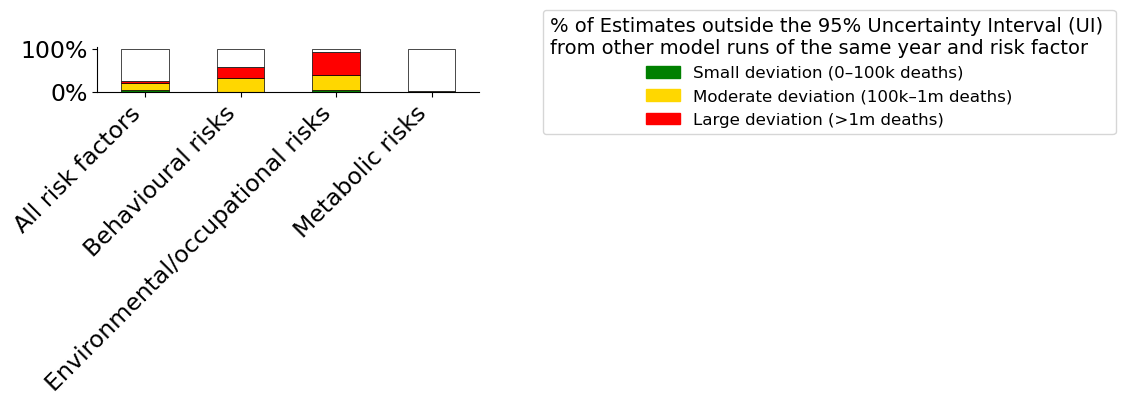

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib.ticker as mtick


# # Define colors
# colors = {'ProportionOutside0': 'green', 'ProportionOutside100k':'gold','ProportionOutside1m':'red','WithinRange': 'white'}


# x=summary_95CI[summary_95CI['df']==1]

# x=x.sort_values(['Overarching_group','Group'])

# # Compute the remaining proportion (to pad to 1)
# # summary_risk_factor['WithinRange'] = 1 - summary_risk_factor['ProportionOutside0']
# # summary_risk_factor['ProportionOutside0'] = summary_risk_factor['ProportionOutside0']-summary_risk_factor['ProportionOutside100k']-summary_risk_factor['ProportionOutside1m']
# # summary_risk_factor['ProportionOutside100k'] = summary_risk_factor['ProportionOutside100k']-summary_risk_factor['ProportionOutside1m']

# # Swap the order so 'ProportionOutside' comes first (i.e., on the bottom)
# percentages = x[['ProportionOutside0','ProportionOutside100k','ProportionOutside1m', 'WithinRange']]

# # Create plot
# fig, ax = plt.subplots(figsize=(6, 4))

# # Stacked bar plot (red will now be on the bottom)
# percentages.plot(kind='bar', stacked=True, ax=ax, legend=False,
#                  color=[colors[col] for col in percentages.columns], 
#                  edgecolor='black', linewidth=0.5)

# # Customize plot
# ax.set_xlabel('', fontsize=14)
# ax.set_ylabel('', fontsize=14)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))  # Format as percentage

# # Set x-axis labels
# ax.set_xticks(np.arange(len(x)))
# ax.set_xticklabels(x['Risk_factor'], rotation=45, ha='right')
# #ax.set_xticklabels([])

# # Create legend
# handles = [plt.Rectangle((0, 0), 1, 1, color=colors[col]) for col in percentages.columns]
# labels = ['Small deviation (0–100k deaths)', 'Moderate deviation (100k–1m deaths)', 'Large deviation (>1m deaths)']  # Swapped legend labels too
# fig.legend(handles, labels, title='% of Estimates outside the 95% Uncertainty Interval (UI) \nfrom other model runs of the same year and risk factor', 
#            bbox_to_anchor=(0.9, 1.05), loc='upper left', fontsize=12, title_fontsize=14)

# # Adjust layout
# plt.tight_layout(rect=[0, 0, 0.85, 1])
# #plt.savefig('./figs/Figure 7 - B Level 1 risks.pdf', bbox_inches='tight')
# plt.show()


/var/folders/7f/53kfyr2s54q972rc_rvv2_q40000gq/T/ipykernel_33055/999783490.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


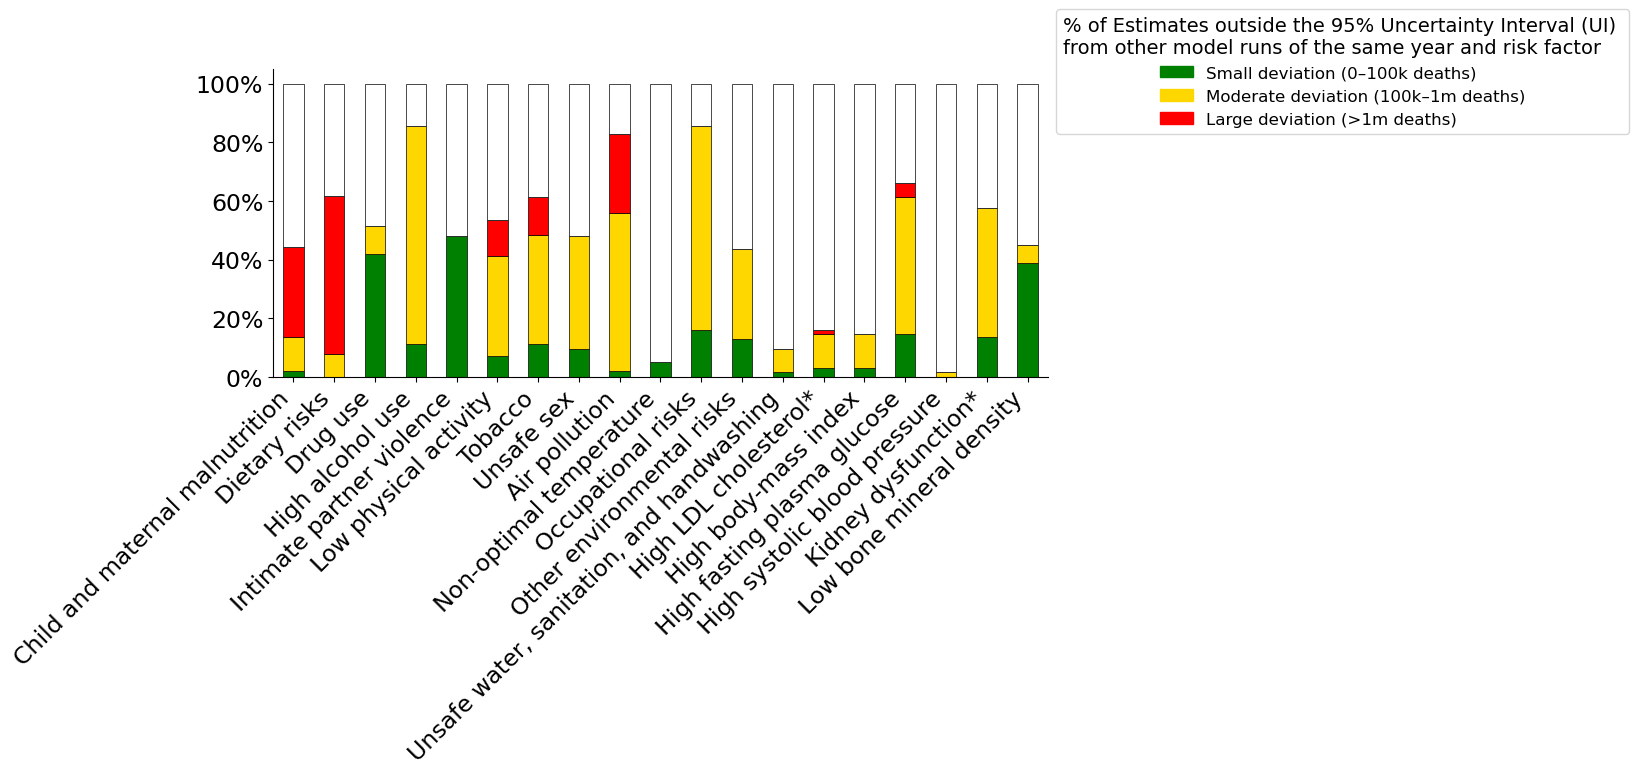

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib.ticker as mtick


# # Define colors
# colors = {'ProportionOutside0': 'green', 'ProportionOutside100k':'gold','ProportionOutside1m':'red','WithinRange': 'white'}


# x=summary_95CI[summary_95CI['df']==2]

# x=x.sort_values(['Overarching_group','Group'])

# # Compute the remaining proportion (to pad to 1)
# # summary_risk_factor['WithinRange'] = 1 - summary_risk_factor['ProportionOutside0']
# # summary_risk_factor['ProportionOutside0'] = summary_risk_factor['ProportionOutside0']-summary_risk_factor['ProportionOutside100k']-summary_risk_factor['ProportionOutside1m']
# # summary_risk_factor['ProportionOutside100k'] = summary_risk_factor['ProportionOutside100k']-summary_risk_factor['ProportionOutside1m']

# # Swap the order so 'ProportionOutside' comes first (i.e., on the bottom)
# percentages = x[['ProportionOutside0','ProportionOutside100k','ProportionOutside1m', 'WithinRange']]

# # Create plot
# fig, ax = plt.subplots(figsize=(10, 4))

# # Stacked bar plot (red will now be on the bottom)
# percentages.plot(kind='bar', stacked=True, ax=ax, legend=False,
#                  color=[colors[col] for col in percentages.columns], 
#                  edgecolor='black', linewidth=0.5)

# # Customize plot
# ax.set_xlabel('', fontsize=14)
# ax.set_ylabel('', fontsize=14)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))  # Format as percentage

# # Set x-axis labels
# ax.set_xticks(np.arange(len(x)))
# ax.set_xticklabels(x['Risk_factor'], rotation=45, ha='right')
# #ax.set_xticklabels([])

# # Create legend
# handles = [plt.Rectangle((0, 0), 1, 1, color=colors[col]) for col in percentages.columns]
# labels = ['Small deviation (0–100k deaths)', 'Moderate deviation (100k–1m deaths)', 'Large deviation (>1m deaths)']  # Swapped legend labels too
# fig.legend(handles, labels, title='% of Estimates outside the 95% Uncertainty Interval (UI) \nfrom other model runs of the same year and risk factor', 
#            bbox_to_anchor=(0.9, 1.05), loc='upper left', fontsize=12, title_fontsize=14)

# # Adjust layout
# plt.tight_layout(rect=[0, 0, 0.85, 1])
# #plt.savefig('./figs/Figure 7 - C Level 2 risks.pdf', bbox_inches='tight')
# plt.show()


/var/folders/7f/53kfyr2s54q972rc_rvv2_q40000gq/T/ipykernel_33055/841572376.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Risk_factor'] = x['Risk_factor'].str.strip('\n')
/var/folders/7f/53kfyr2s54q972rc_rvv2_q40000gq/T/ipykernel_33055/841572376.py:46: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


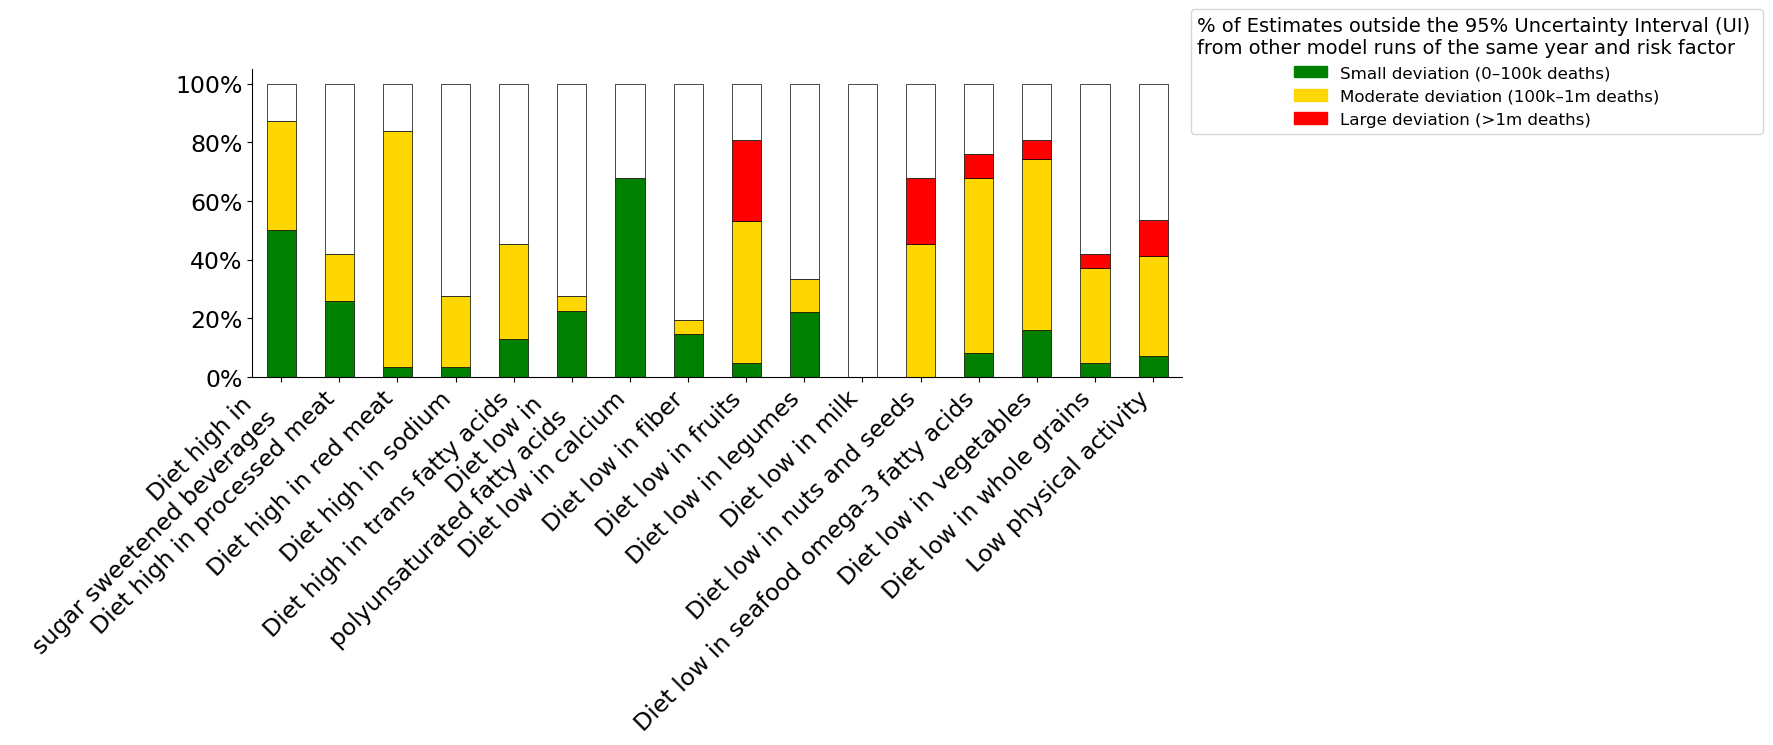

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib.ticker as mtick


# # Define colors
# colors = {'ProportionOutside0': 'green', 'ProportionOutside100k':'gold','ProportionOutside1m':'red','WithinRange': 'white'}
# p_dietary_risks=dietary_risks+['Low physical activity']
# x=summary_95CI_individual[summary_95CI_individual.Risk_factor.isin(p_dietary_risks)]

# # for formatting purposes
# x['Risk_factor'] = x['Risk_factor'].str.strip('\n')

# x=x.sort_values(['Overarching_group','Group'])

# # Swap the order so 'ProportionOutside' comes first (i.e., on the bottom)
# percentages = x[['ProportionOutside0','ProportionOutside100k','ProportionOutside1m', 'WithinRange']]

# # Create plot
# fig, ax = plt.subplots(figsize=(12, 4))

# # Stacked bar plot (red will now be on the bottom)
# percentages.plot(kind='bar', stacked=True, ax=ax, legend=False,
#                  color=[colors[col] for col in percentages.columns], 
#                  edgecolor='black', linewidth=0.5)

# # Customize plot
# ax.set_xlabel('', fontsize=14)
# ax.set_ylabel('', fontsize=14)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))  # Format as percentage

# # Set x-axis labels
# ax.set_xticks(np.arange(len(x)))
# ax.set_xticklabels(x['Risk_factor'], rotation=45, ha='right')
# #ax.set_xticklabels([])

# # Create legend
# handles = [plt.Rectangle((0, 0), 1, 1, color=colors[col]) for col in percentages.columns]
# labels = ['Small deviation (0–100k deaths)', 'Moderate deviation (100k–1m deaths)', 'Large deviation (>1m deaths)']  # Swapped legend labels too
# fig.legend(handles, labels, title='% of Estimates outside the 95% Uncertainty Interval (UI) \nfrom other model runs of the same year and risk factor', 
#            bbox_to_anchor=(0.9, 1.05), loc='upper left', fontsize=12, title_fontsize=14)

# # Adjust layout
# plt.tight_layout(rect=[0, 0, 0.85, 1])
# #plt.savefig('./figs/Figure 7 - D Dietary risks.pdf', bbox_inches='tight')
# plt.show()